# Exploración

Exploración realizada sobre un subcojunto de transacciones antes de ser procesado.

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [3]:
#tsx = pd.read_csv('../data/example_tsx.csv', sep=';')#Añades información de storage
#merged = pd.read_csv('../data/example_merged.csv', sep=';')
#contracts = pd.read_csv('../data/contracts100.csv', sep=';')
#preprocessed = pd.read_csv('../data/example_preprocessed.csv', sep=';')

In [4]:
df_merged = []
for filename in os.listdir('../data/merged'):
    if not filename.endswith('.csv'):
        continue
    filepath = os.path.join('../data/merged', filename)
    df = pd.read_csv(filepath, sep=';')#, index_col='hash'
    df_merged.append(df)
tsx = pd.concat(df_merged)

In [5]:
tsx['signature'] = tsx['input'].astype(str).map(lambda x: x[:10])

In [6]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', 25)
print(tsx.head())

                       hash                to_address                     input           block_timestamp  receipt_gas_used            storage_before   signature
0  0xecece396b6639da101d...  0xdac17f958d2ee523a22...  0xa9059cbb00000000000...  2024-01-14 02:32:35+0...             46097  {'0x00000000000000000...  0xa9059cbb
1  0xc49ba9d43bb4e1f07a1...  0xdac17f958d2ee523a22...  0xa9059cbb00000000000...  2024-01-14 02:32:35+0...             46085  {'0x00000000000000000...  0xa9059cbb
2  0xa9b8f947ed7acf89292...  0xc944e90c64b2c07662a...  0xa9059cbb00000000000...  2024-01-14 02:35:35+0...             29754                       NaN  0xa9059cbb
3  0xecc5760feec1cf2676f...  0x06450dee7fd2fb8e390...  0x1c56030500000000000...  2024-01-14 02:38:23+0...             73623                       NaN  0x1c560305
4  0xb3166a5b637a5ca34f5...  0x29469395eaf6f95920e...  0xe7efc17800000000000...  2024-01-14 02:39:59+0...            146356                       NaN  0xe7efc178


### Distribución del gas

In [7]:
tsx['receipt_gas_used'].describe()

count    1.076432e+07
mean     1.289631e+05
std      1.926734e+05
min      2.104000e+04
25%      4.615700e+04
50%      7.362300e+04
75%      1.588040e+05
max      2.115232e+07
Name: receipt_gas_used, dtype: float64

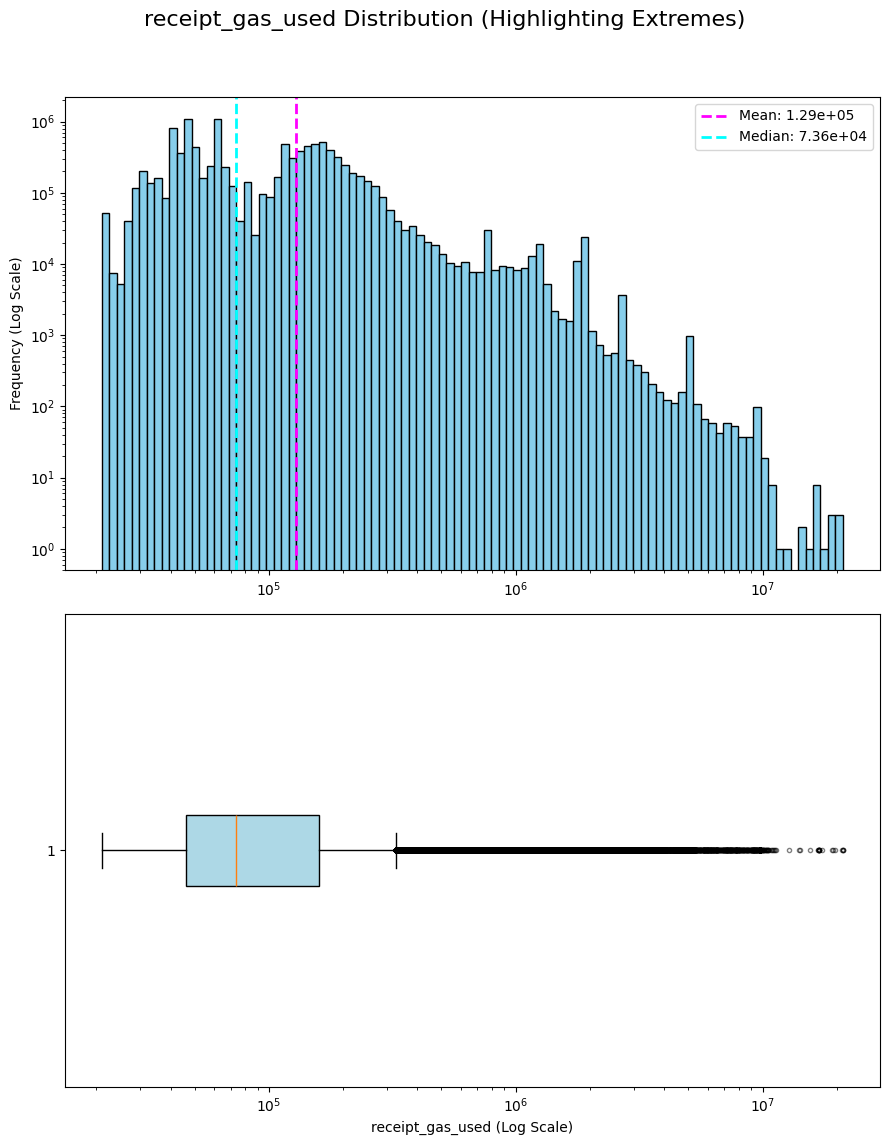

In [35]:
# Get the label column
label = tsx['receipt_gas_used']

# Create a figure for 2 subplots
fig, ax = plt.subplots(2, 1, figsize = (9,12))

# --- 1. HISTOGRAMA CON ESCALA LOGARÍTMICA ---
# Usamos bins logarítmicos para que las barras no se amontonen a la izquierda
bins = np.logspace(np.log10(label.min() if label.min() > 0 else 1), np.log10(label.max()), 100)
ax[0].hist(label, bins=bins, color='skyblue', edgecolor='black')
ax[0].set_xscale('log') # Escala logarítmica en X
ax[0].set_yscale('log') # Escala logarítmica en Y (opcional, ayuda si hay mucha diferencia de frecuencia)
ax[0].set_ylabel('Frequency (Log Scale)')

# Líneas de tendencia (Media y Mediana)
ax[0].axvline(label.mean(), color='magenta', linestyle='dashed', linewidth=2, label=f'Mean: {label.mean():.2e}')
ax[0].axvline(label.median(), color='cyan', linestyle='dashed', linewidth=2, label=f'Median: {label.median():.2e}')
ax[0].legend()

# --- 2. BOXPLOT CON ESCALA LOGARÍTMICA ---
ax[1].boxplot(label, vert=False, patch_artist=True, 
              boxprops=dict(facecolor='lightblue'),
              flierprops=dict(marker='o', color='red', markersize=3, alpha=0.5)) # Outliers en rojo
ax[1].set_xscale('log') # ESTO ES LO QUE SALVA EL GRÁFICO
ax[1].set_xlabel('receipt_gas_used (Log Scale)')

# Add a title to the Figure
fig.suptitle('receipt_gas_used Distribution (Highlighting Extremes)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Información de Storage

In [8]:
total = len(tsx)
with_storage = tsx['storage_before'].notna().sum()
coverage = with_storage / total if total > 0 else 0

print(f"Total transacciones: {total}")
print(f"Con storage: {with_storage}")
print(f"Sin storage: {total - with_storage}")
print(f"Cobertura: {coverage:.2%}")

Total transacciones: 10764324
Con storage: 2797946
Sin storage: 7966378
Cobertura: 25.99%


### Tamaño del dataset

In [9]:
df_counts = tsx.groupby(['to_address', 'signature']).size().reset_index(name='n_transacciones')

In [10]:
total_pares = len(df_counts)
total_transacciones = tsx.shape[0]

print(f"Hay {total_pares} combinaciones únicas de contrato y función.")
print(f"En promedio, cada par se usa {total_transacciones / total_pares:.2f} veces.")

Hay 11889 combinaciones únicas de contrato y función.
En promedio, cada par se usa 905.40 veces.


In [11]:
validas = df_counts[df_counts['n_transacciones'] > 10000]
cantidad = len(validas)
print(f"Número de pares (contrato, signature) con más de 10,000 transacciones: {cantidad}")

Número de pares (contrato, signature) con más de 10,000 transacciones: 140


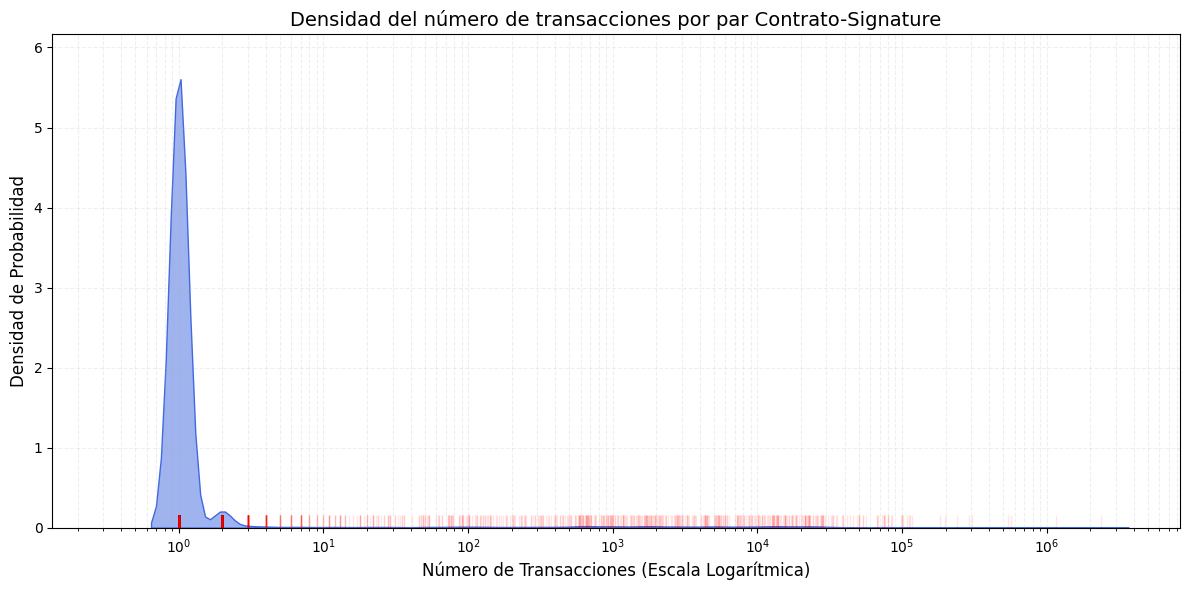

In [12]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df_counts, x='n_transacciones', fill=True, 
            color="royalblue", log_scale=True, bw_adjust=0.6, alpha=0.5)

sns.rugplot(data=df_counts, x='n_transacciones', color="red", alpha=0.1)

plt.title('Densidad del número de transacciones por par Contrato-Signature', fontsize=14)
plt.xlabel('Número de Transacciones (Escala Logarítmica)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.2)

plt.tight_layout()
plt.show()

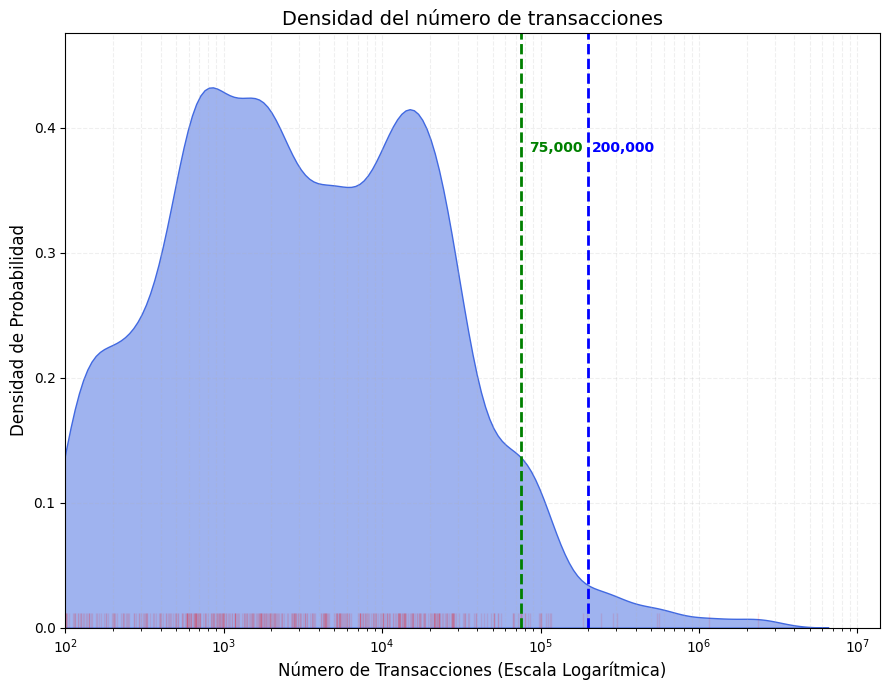

In [15]:
# 1. Filtrar el DataFrame para obtener solo registros con n_transacciones >= 100
df_filtered = df_counts[df_counts['n_transacciones'] >= 100]

# 2. Configuración de la gráfica
plt.figure(figsize=(9, 7))

# Usamos el DataFrame filtrado para el KDE y el Rugplot
sns.kdeplot(data=df_filtered, x='n_transacciones', fill=True, 
            color="royalblue", log_scale=True, bw_adjust=0.6, alpha=0.5)

sns.rugplot(data=df_filtered, x='n_transacciones', color="red", alpha=0.1)

# 3. Personalización
plt.title('Densidad del número de transacciones', fontsize=14)
plt.xlabel('Número de Transacciones (Escala Logarítmica)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.2)


plt.axvline(x=75000, color="green", linestyle="--", linewidth=2, label="Límite 200k")
plt.text(85000, plt.ylim()[1] * 0.8, '75,000', color='green', fontweight='bold')
plt.axvline(x=200000, color="blue", linestyle="--", linewidth=2, label="Límite 200k")
plt.text(210000, plt.ylim()[1] * 0.8, '200,000', color='blue', fontweight='bold')

# Opcional: Ajustar el límite inferior del eje X para que empiece en 100
plt.xlim(left=100)

plt.tight_layout()
plt.show()

### Contratos

In [8]:
contracts.head()

,contract,abi,proxy_abi
0,0xdac17f958d2ee523a22...,"[{""constant"":True,""in...",NaN
1,0x3fc91a3afd70395cd49...,"[{""inputs"":[{""compone...",NaN
2,0x7a250d5630b4cf53973...,"[{""inputs"":[{""interna...",NaN
3,0xef1c6e67703c7bd7107...,"[{""inputs"":[{""compone...",NaN
4,0xa0b86991c6218b36c1d...,"[{""constant"":False,""i...","[{""anonymous"":False,""..."


In [ ]:
grouped_contracts_signature = tsx.groupby((['to_address', 'signature'])

In [ ]:
example = grouped_contracts_signature.get_group(('0x95ad61b0a150d79219dcf64e1e6cc01f0b64c4ce', '0xa9059cbb'))
example = example.sort_values(by='block_timestamp')

example.plot(x='block_timestamp', y='receipt_gas_used', marker='o', linestyle='-', figsize=(10, 6))

In [ ]:
example = grouped_contracts_signature.get_group(('0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48', '0xa9059cbb'))
example = example.sort_values(by='block_timestamp')

example.plot(x='block_timestamp', y='receipt_gas_used', marker='o', linestyle='-', figsize=(10, 6))

In [ ]:
example = grouped_contracts_signature.get_group(('0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad', '0x3593564c'))
example = example.sort_values(by='block_timestamp')

example.plot(x='block_timestamp', y='receipt_gas_used', marker='o', linestyle='-', figsize=(10, 6))

## Ejemplo Preprocessed

Cambiamos el nombre de (address,uint256,uint256,address,address,address,uint256,uint256,uint8,uint256,uint256,bytes32,uint256,bytes32,bytes32,uint256,(uint256,address),bytes)_parameters a 'parameters'

In [10]:
cols = list(preprocessed.columns)
cols[0] = 'parameters'
preprocessed.columns = cols
preprocessed.head()

,parameters,block_timestamp,hash,input,input_len,receipt_gas_used,signature,strg_len,strgslot_1,strgslot_2,strgslot_3,strgval_1,strgval_2,strgval_3,to_address
0,0.0,2023-01-14 19:33:23+0...,0xacf619adad0892f580d...,0xfb0f3ee100000000000...,1818.0,145740,0xfb0f3ee1,3.0,1.0,2.0,3.0,1.0,2.0,0.0,0x00000000006c3852cbe...
1,665.0,2023-01-14 03:04:11+0...,0x9afd25b77e4269496de...,0xfb0f3ee100000000000...,1754.0,157230,0xfb0f3ee1,3.0,1.0,4.0,5.0,1.0,0.0,0.0,0x00000000006c3852cbe...
2,727.0,2023-01-14 05:00:47+0...,0xd37f825010372988916...,0xfb0f3ee100000000000...,1818.0,148627,0xfb0f3ee1,3.0,1.0,6.0,7.0,1.0,0.0,0.0,0x00000000006c3852cbe...
3,753.0,2023-01-14 03:05:23+0...,0x9584cba316e871e0ae9...,0xfb0f3ee100000000000...,1700.0,143183,0xfb0f3ee1,3.0,1.0,8.0,9.0,1.0,0.0,0.0,0x00000000006c3852cbe...
4,665.0,2023-01-14 11:05:59+0...,0x60dd2be65aed9aa0e7b...,0xfb0f3ee100000000000...,1738.0,145392,0xfb0f3ee1,3.0,1.0,10.0,11.0,1.0,0.0,0.0,0x00000000006c3852cbe...


De estas quitamos siempre:
'hash','to_address', 'input', 'signature', 'receipt_gas_used', block_timestamp

In [12]:
preprocessed.drop(['hash','to_address', 'input', 'signature', 'receipt_gas_used','block_timestamp'], axis=1) 

,parameters,input_len,strg_len,strgslot_1,strgslot_2,strgslot_3,strgval_1,strgval_2,strgval_3
0,0.0,1818.0,3.0,1.0,2.0,3.0,1.0,2.0,0.0
1,665.0,1754.0,3.0,1.0,4.0,5.0,1.0,0.0,0.0
2,727.0,1818.0,3.0,1.0,6.0,7.0,1.0,0.0,0.0
3,753.0,1700.0,3.0,1.0,8.0,9.0,1.0,0.0,0.0
4,665.0,1738.0,3.0,1.0,10.0,11.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
192,754.0,1802.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193,724.0,1690.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
194,725.0,1818.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
195,727.0,1690.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
numeric_features = preprocessed.select_dtypes(include=['number']).columns.tolist()
print(preprocessed[numeric_features].describe())

       parameters    input_len  receipt_gas_used    strg_len  strgslot_1  strgslot_2  strgslot_3   strgval_1   strgval_2   strgval_3
count  197.000000   197.000000        197.000000  197.000000  197.000000  197.000000  197.000000  197.000000  197.000000  197.000000
mean   661.593909  1777.258883     161379.035533    0.837563    0.279188   15.507614   15.573604    0.279188    0.101523    0.106599
std    210.928795    65.312428      19677.623453    1.349229    0.449743   29.988879   30.192426    0.449743    1.156105    0.916853
min      0.000000  1562.000000     122052.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
25%    725.000000  1746.000000     147766.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
50%    727.000000  1818.000000     160916.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
75%    728.000000  1818.000000     175584.000000    3.000000    1.000

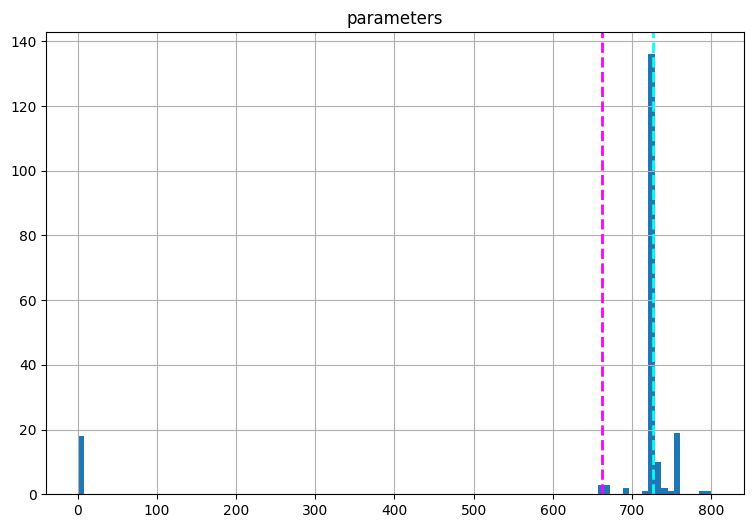

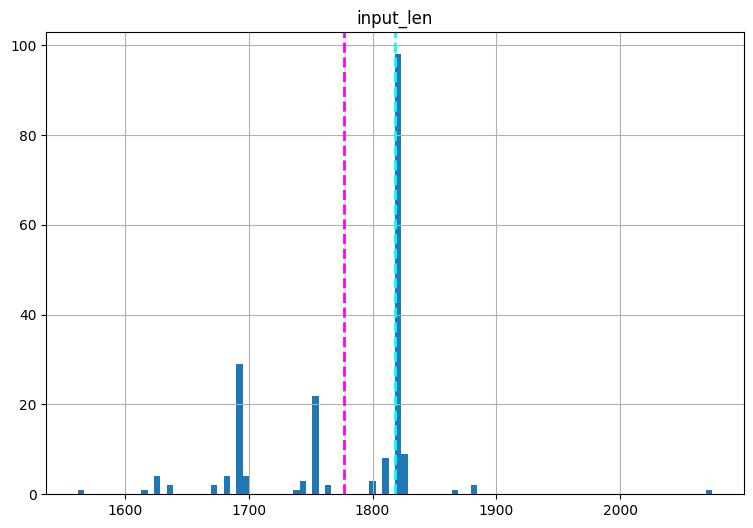

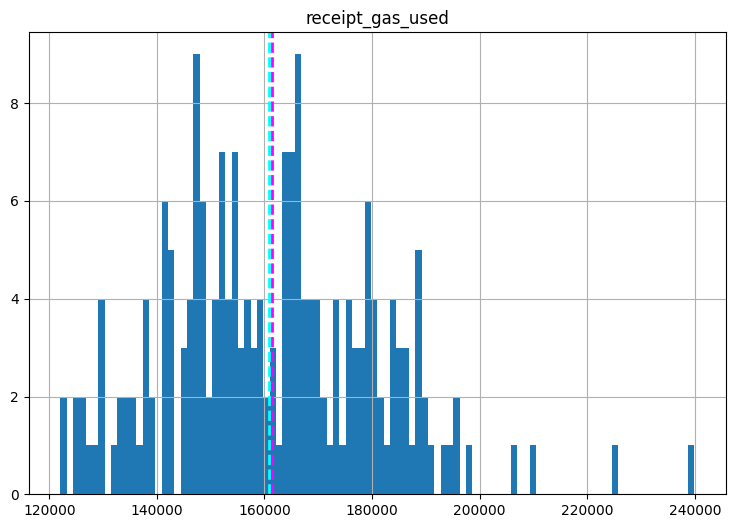

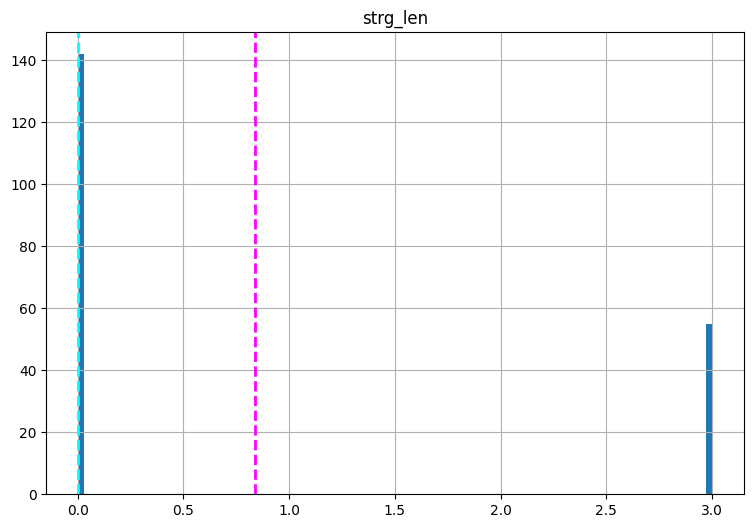

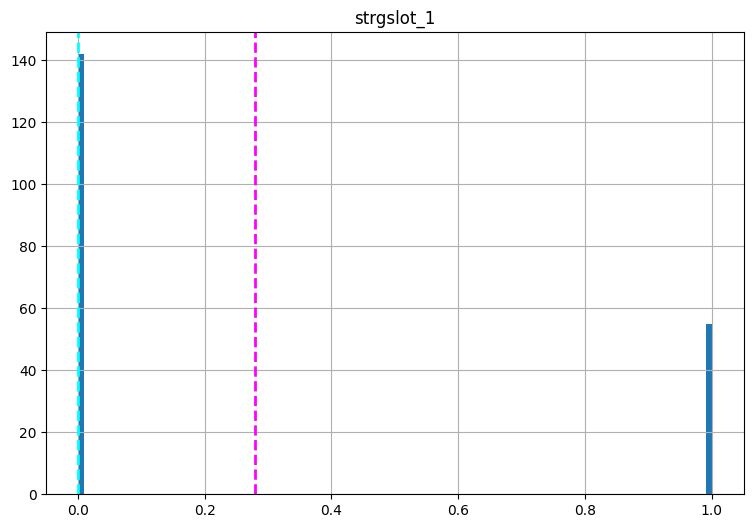

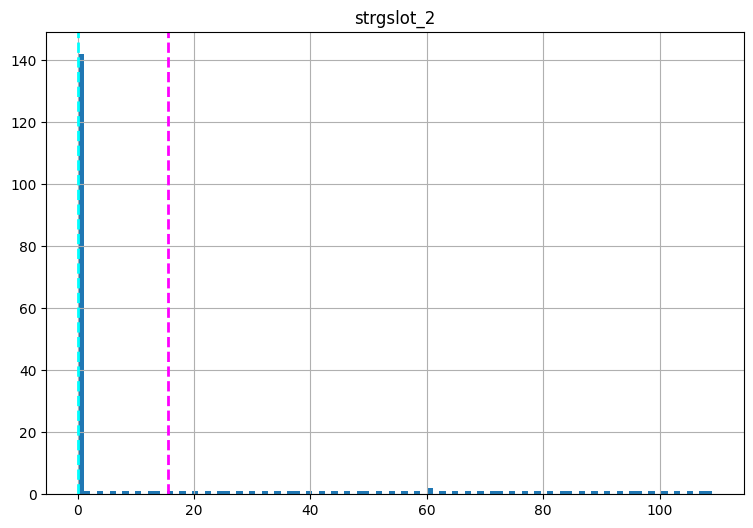

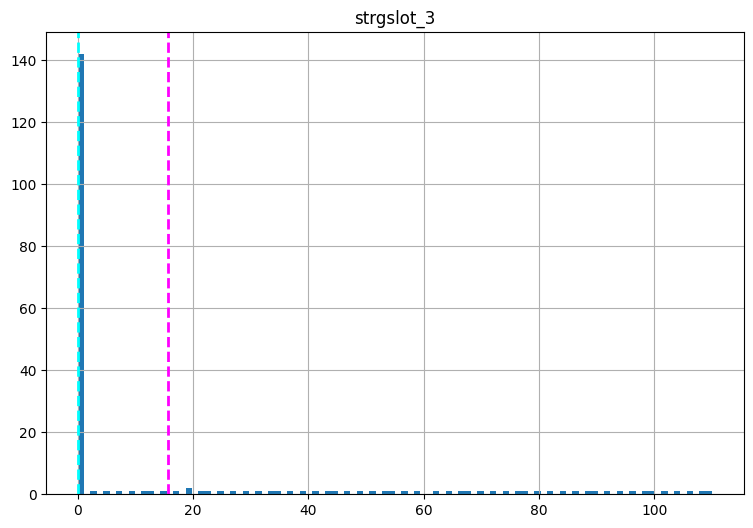

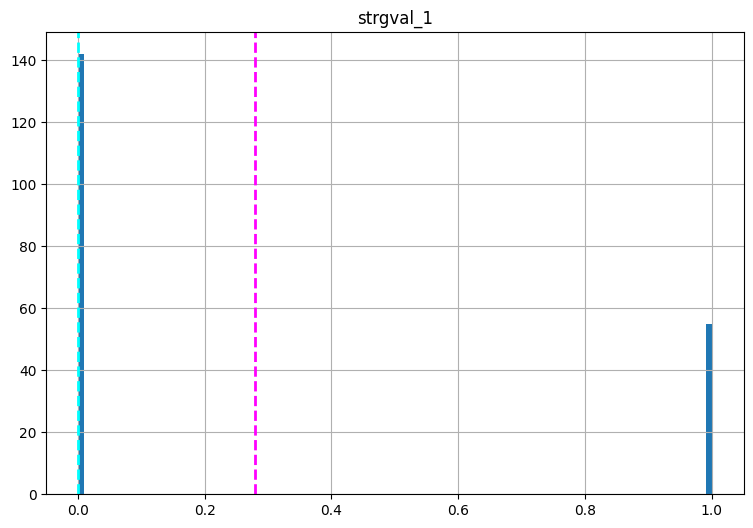

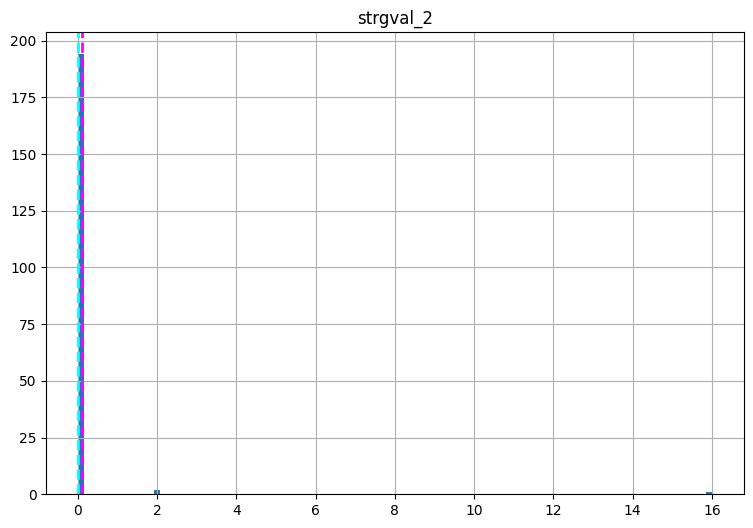

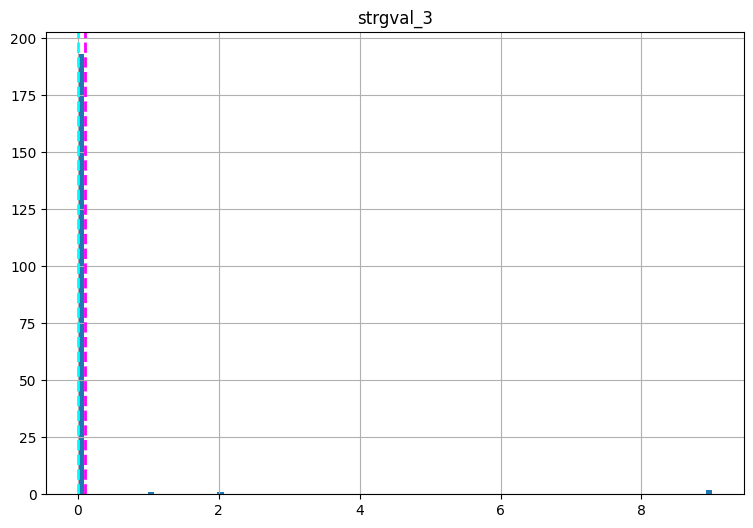

In [14]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = preprocessed[col]
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()

## Ejemplos consumo gas a lo largo del tiempo de un contrato

In [15]:
grouped_contracts_signature = merged.groupby(['to_address', 'signature'])

<Axes: xlabel='block_timestamp'>

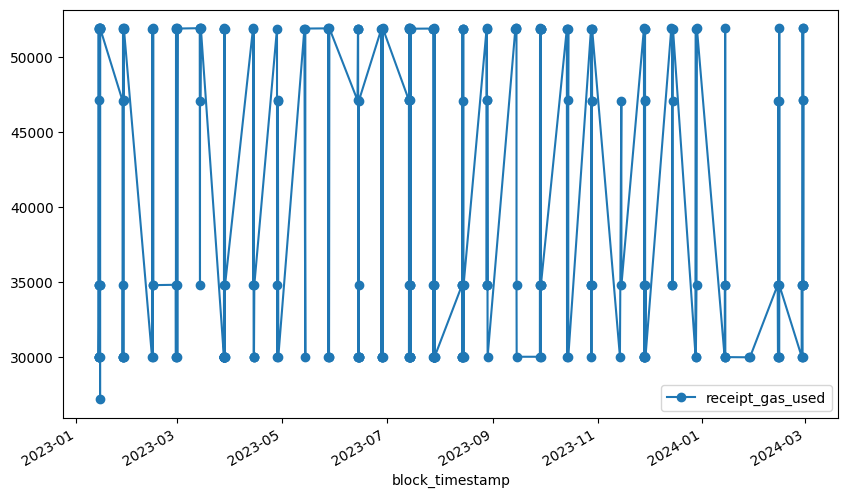

In [16]:
example = grouped_contracts_signature.get_group(('0x95ad61b0a150d79219dcf64e1e6cc01f0b64c4ce', '0xa9059cbb'))
example = example.sort_values(by='block_timestamp')

example.plot(x='block_timestamp', y='receipt_gas_used', marker='o', linestyle='-', figsize=(10, 6))

<Axes: xlabel='block_timestamp'>

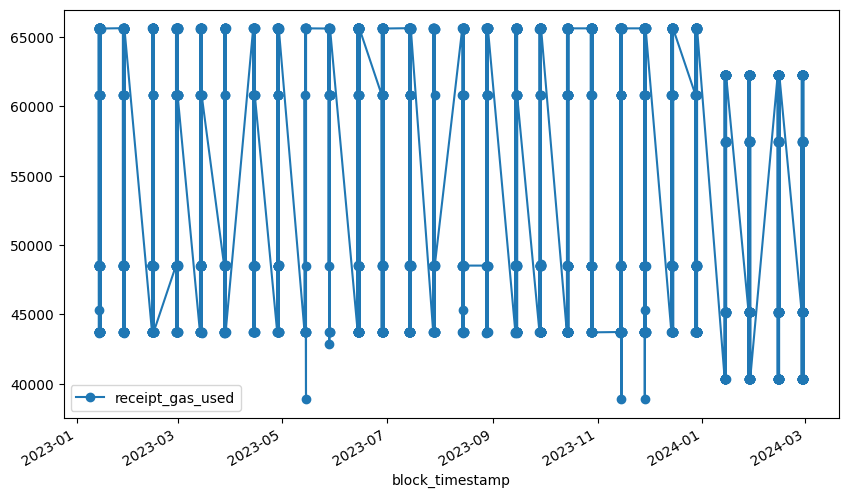

In [17]:
example = grouped_contracts_signature.get_group(('0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48', '0xa9059cbb'))
example = example.sort_values(by='block_timestamp')

example.plot(x='block_timestamp', y='receipt_gas_used', marker='o', linestyle='-', figsize=(10, 6))

<Axes: xlabel='block_timestamp'>

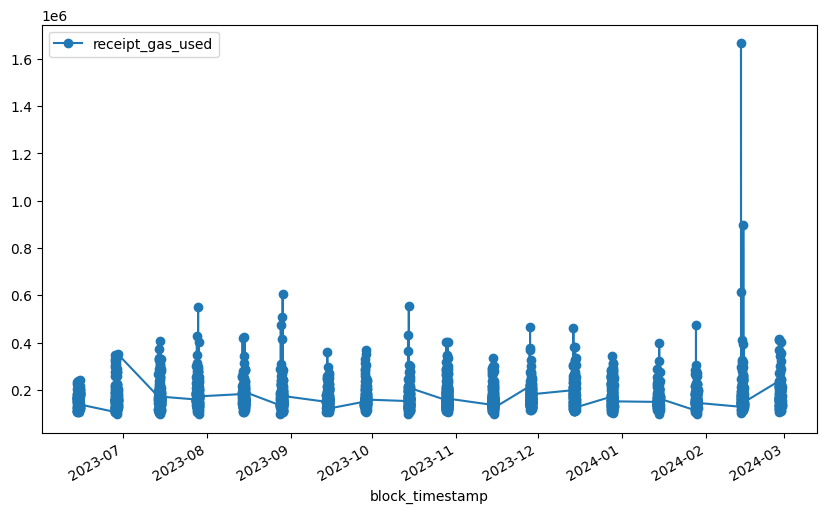

In [18]:
example = grouped_contracts_signature.get_group(('0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad', '0x3593564c'))
example = example.sort_values(by='block_timestamp')

example.plot(x='block_timestamp', y='receipt_gas_used', marker='o', linestyle='-', figsize=(10, 6))